# Extension 2: MLLMU-Bench Generalization Study

**Objective**: Evaluate whether unlearning method rankings generalize across benchmarks (FIUBench vs MLLMU-Bench).

**Proposal Requirements**:
- Model: LLaVA-Phi-3-mini-3B with LoRA (fine-tuning + unlearning)
- Dataset: MLLMU-Bench (100 fictional identities: 50 forget, 50 retain)
- Methods: GA, GD, KL, PO (FIUBench suite, NOT NPO)
- Metrics: D_unlearn, D_retain, MMBench
- Primary Analysis: Kendall's τ correlation between FIUBench and MLLMU-Bench method rankings
- Secondary: CMLD (cross-modal leakage) comparison, radar charts

**Key Constraint**: Cannot reproduce PULSE's absolute numbers—only test if relative method rankings are consistent across benchmarks.

## Cell 1: Setup & Paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import subprocess

result = subprocess.run(
    "git clone https://YOUR_TOKEN@github.com/akashyall34/FIUBench_Reproducing.git /content/FIUBench_Reproducing",
    shell=True, capture_output=True, text=True
)
print(result.stdout or result.stderr)

Cloning into '/content/FIUBench_Reproducing'...



In [3]:
import subprocess
from pathlib import Path

PROJECT_ROOT = '/content/FIUBench_Reproducing'

print(f"Pulling latest changes from GitHub...\n")

# Stash local changes first to avoid conflicts
print("Stashing local changes...")
result = subprocess.run(
    "git stash",
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    shell=True
)
if result.returncode == 0 and result.stdout.strip():
    print(result.stdout)
else:
    print("(no local changes to stash)")

# Now pull
result = subprocess.run(
    "git pull",
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    shell=True
)

if result.returncode == 0:
    print("✅ Repository updated")
    print(result.stdout)
else:
    print("❌ Pull failed")
    print(result.stderr)

Pulling latest changes from GitHub...

Stashing local changes...
No local changes to save

✅ Repository updated
Already up to date.



In [4]:
import subprocess, sys

deps = [
    "torch==2.4.1",
    "transformers==4.48.0",
    "xtuner==0.2.0",
    "accelerate==0.34.2",
    "datasets==2.21.0",
    "peft==0.13.2",
    "triton",
    "pillow",
    "scikit-learn",
    "rouge-score",
    "open-clip-torch",
    "hf_transfer",
]

for dep in deps:
    subprocess.run(f"{sys.executable} -m pip install -q {dep}", shell=True)
# Remove broken bitsandbytes (not needed for bfloat16 LoRA)
subprocess.run(f"{sys.executable} -m pip uninstall -y bitsandbytes", shell=True, capture_output=True)

import transformers, torch
print(f"✅ torch={torch.__version__}  transformers={transformers.__version__}")


✅ torch=2.10.0+cu128  transformers=4.48.0


In [5]:
import os
import sys
import torch
import json
import subprocess
import time
from pathlib import Path
from huggingface_hub import snapshot_download

# ─── Detect Colab Environment ──────────────────────────────────────────────
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")

# ─── Mount Google Drive (Colab only) ───────────────────────────────────────
if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)
    print("Google Drive mounted at /content/drive")

# ─── Device ───────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f}GB')

# ─── Configuration (Per Proposal) ──────────────────────────────────────────
BASE_MODEL = 'xtuner/llava-phi-3-mini-hf'  # Proposal requirement
FORGET_SPLIT = 'forget_5'  # Pre-made split in MLLMU-Bench
RETAIN_SPLIT = 'retain_95'  # Corresponding retain set

# ─── Paths (Colab vs Local) ───────────────────────────────────────────────
if IN_COLAB:
    # Google Drive paths - use fiubench_checkpoints
    CKPT_DIR = Path('/content/drive/MyDrive/fiubench_checkpoints/extension2')
    OUTPUT_DIR = Path('/content/drive/MyDrive/fiubench_checkpoints/extension2/outputs')
    CACHE_DIR = Path('/content/drive/MyDrive/fiubench_cache/mllmu')
    MLLMU_DIR = Path('/content/FIUBench_Reproducing/MLLMU-Bench')  # From cloned repo
    print("Using Google Drive paths (fiubench_checkpoints)")
else:
    # Local paths
    WORK_DIR = Path('/Users/akashy/Library/CloudStorage/OneDrive-UniversityofSouthFlorida/Projects/FIUBench_Reproducing')
    CKPT_DIR = WORK_DIR / 'checkpoints' / 'extension2'
    OUTPUT_DIR = WORK_DIR / 'outputs' / 'extension2'
    CACHE_DIR = WORK_DIR / 'cache' / 'mllmu'
    MLLMU_DIR = WORK_DIR / 'MLLMU-Bench'
    print("Using local paths")

DATA_DIR = CACHE_DIR / 'MLLMU-Bench'

# Create directories
for d in [CKPT_DIR, OUTPUT_DIR, CACHE_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'\nModel: {BASE_MODEL}')
print(f'Split: {FORGET_SPLIT} / {RETAIN_SPLIT}')
print(f'Paths:')
print(f'  MLLMU-Bench repo: {MLLMU_DIR}')
print(f'  Data cache: {DATA_DIR}')
print(f'  Checkpoints: {CKPT_DIR}')
print(f'  Outputs: {OUTPUT_DIR}')

# ─── HuggingFace Authentication ────────────────────────────────────────────
if 'HF_TOKEN' not in os.environ:
    print('\nHF_TOKEN set (via login() in Cell 0)')

print('\nSetup complete')

Running in Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted at /content/drive
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1GB
Using Google Drive paths (fiubench_checkpoints)

Model: xtuner/llava-phi-3-mini-hf
Split: forget_5 / retain_95
Paths:
  MLLMU-Bench repo: /content/FIUBench_Reproducing/MLLMU-Bench
  Data cache: /content/drive/MyDrive/fiubench_cache/mllmu/MLLMU-Bench
  Checkpoints: /content/drive/MyDrive/fiubench_checkpoints/extension2
  Outputs: /content/drive/MyDrive/fiubench_checkpoints/extension2/outputs

HF_TOKEN set (via login() in Cell 0)

Setup complete


In [6]:
print('='*60)
print('Downloading MLLMU-Bench Dataset & Pre-Made Splits')
print('='*60)

# ─── Dataset ───────────────────────────────────────────────────────────────
try:
    snapshot_download(
        repo_id='MLLMMU/MLLMU-Bench',
        local_dir=str(DATA_DIR),
        repo_type='dataset',
    )
    print(f'✅ Dataset downloaded to {DATA_DIR}')
except Exception as e:
    print(f'⚠️  Dataset error (may already exist): {e}')

# Verify pre-made splits exist
print('\n' + '-'*60)
print('Verification of Pre-Made Splits:')
print('-'*60)

forget_path = DATA_DIR / FORGET_SPLIT
retain_path = DATA_DIR / RETAIN_SPLIT

forget_files = list(forget_path.glob('*.json')) + list(forget_path.glob('*.parquet'))
retain_files = list(retain_path.glob('*.json')) + list(retain_path.glob('*.parquet'))

if forget_files:
    print(f'✅ {FORGET_SPLIT}: {len(forget_files)} files found')
else:
    print(f'⚠️  {FORGET_SPLIT}: NO FILES FOUND')
    print(f'   Expected path: {forget_path}')

if retain_files:
    print(f'✅ {RETAIN_SPLIT}: {len(retain_files)} files found')
else:
    print(f'⚠️  {RETAIN_SPLIT}: NO FILES FOUND')
    print(f'   Expected path: {retain_path}')

# Also verify fine-tuning data
ft_data = list((DATA_DIR / 'ft_Data').glob('*.parquet')) if (DATA_DIR / 'ft_Data').exists() else []
test_set = list((DATA_DIR / 'Test_Set').glob('*.parquet')) if (DATA_DIR / 'Test_Set').exists() else []

if ft_data:
    print(f'✅ ft_Data: {len(ft_data)} parquet files')
else:
    print(f'⚠️  ft_Data: NOT FOUND')

if test_set:
    print(f'✅ Test_Set: {len(test_set)} parquet files')
else:
    print(f'⚠️  Test_Set: NOT FOUND')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

✅ Dataset downloaded to /content/drive/MyDrive/fiubench_cache/mllmu/MLLMU-Bench

------------------------------------------------------------
Verification of Pre-Made Splits:
------------------------------------------------------------
✅ forget_5: 1 files found
✅ retain_95: 1 files found
✅ ft_Data: 1 parquet files
✅ Test_Set: 2 parquet files


In [7]:
import torch
import pandas as pd
import json
from pathlib import Path
from io import BytesIO
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import LlavaForConditionalGeneration, AutoProcessor
from peft import LoraConfig, get_peft_model
from torch.optim import AdamW
from tqdm import tqdm


class MllmuFtDataset(Dataset):
    def __init__(self, parquet_path, max_identities=100):
        df = pd.read_parquet(parquet_path)
        self.samples = []
        identity_count = {}
        identities_seen = set()

        for idx, row in df.iterrows():
            if len(identities_seen) >= max_identities:
                break

            identity = row['ID']
            if identity not in identities_seen:
                identities_seen.add(identity)
                identity_count[identity] = 0

            image_bytes = row['image']['bytes']
            img = Image.open(BytesIO(image_bytes)).convert('RGB')

            metadata = json.loads(row['metadata'])

            for qa_pair in metadata:
                question = qa_pair.get('Question') or qa_pair.get('Additional_question')
                answer = qa_pair.get('Answer') or qa_pair.get('Additional_answer')

                if question and answer:
                    self.samples.append({
                        'identity': identity,
                        'image': img,
                        'question': str(question),
                        'answer': str(answer)
                    })
                    identity_count[identity] += 1

            if len(identities_seen) >= max_identities:
                break

        print(f"Loaded {len(self.samples)} samples from {len(identity_count)} identities")
        print(f"Structure: 100 identities × 19 QA pairs = ~1900 samples total")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_fn_llava(batch, processor):
    images = []
    texts = []

    for sample in batch:
        images.append(sample['image'])
        question = sample['question']
        answer = sample['answer']
        prompt = "<|user|>\n<image>\n" + question.capitalize() + "<|end|>\n<|assistant|>\n" + answer
        texts.append(prompt)

    inputs = processor(text=texts, images=images, padding=True, return_tensors="pt")

    labels = inputs['input_ids'].clone()
    pad_token_id = processor.tokenizer.pad_token_id
    labels[labels == pad_token_id] = -100
    inputs['labels'] = labels

    return inputs


print("✅ Dataset class & collate_fn ready")

✅ Dataset class & collate_fn ready


In [8]:
print('\n' + '='*60)
print('FINE-TUNING: LoRA on MLLMU-Bench ft_Data')
print('='*60)

vanilla_local = CKPT_DIR / 'vanilla_model'
vanilla_local.mkdir(parents=True, exist_ok=True)

ft_data_files = list((DATA_DIR / 'ft_Data').glob('*.parquet'))
if not ft_data_files:
    print('❌ ft_Data not found')
else:
    ft_data_path = ft_data_files[0]
    print(f'✅ Data: {ft_data_path.name}')
    print(f'Configuration: 100 identities | 19 QA pairs each | ~1900 samples')
    print(f'Batch: 4 | LR: 2e-5 | Epochs: 5 | LoRA r=16\n')

    model = LlavaForConditionalGeneration.from_pretrained(
        BASE_MODEL,
        torch_dtype=torch.bfloat16,
        device_map="auto"
    )

    processor = AutoProcessor.from_pretrained(BASE_MODEL)
    processor.tokenizer.padding_side = "right"
    processor.patch_size = 14

    print("Enabling gradient checkpointing...")
    model.gradient_checkpointing_enable()

    print("Setting up LoRA adapters...")
    lora_config = LoraConfig(
        r=16,
        lora_alpha=16,
        lora_dropout=0.05,
        target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        init_lora_weights="gaussian",
    )

    model = get_peft_model(model, lora_config)
    model.enable_input_require_grads()
    model.print_trainable_parameters()

    print("\nLoading ft_Data dataset...")
    dataset = MllmuFtDataset(str(ft_data_path), max_identities=100)
    dataloader = DataLoader(
        dataset,
        batch_size=4,
        shuffle=True,
        collate_fn=lambda x: collate_fn_llava(x, processor)
    )

    optimizer = AdamW(model.parameters(), lr=2e-5)
    model.train()
    loss_history = []

    print(f"Starting training on {len(dataset)} samples...\n")
    t0 = time.time()

    for epoch in range(5):
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch + 1}/5")
        epoch_loss = 0.0

        for batch in progress_bar:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            epoch_loss = epoch_loss + loss.item()
            loss_history.append(loss.item())

            recent_losses = loss_history[-100:]
            avg_loss = sum(recent_losses) / len(recent_losses)
            progress_bar.set_postfix({"loss": avg_loss})

        total_batches = len(dataloader)
        final_avg_loss = epoch_loss / total_batches
        print(f"Epoch {epoch + 1}/5 | Loss: {final_avg_loss:.4f}")

    elapsed = time.time() - t0
    h, m, s = int(elapsed//3600), int((elapsed%3600)//60), int(elapsed%60)

    print("\nSaving fine-tuned model...")
    model = model.merge_and_unload()
    vanilla_local.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(str(vanilla_local))
    processor.save_pretrained(str(vanilla_local))

    print(f'\n{"="*60}')
    print(f'✅ FINE-TUNING COMPLETE')
    print(f'{"="*60}')
    print(f'Time: {h}h {m}m {s}s')
    print(f'Samples: {len(dataset)} (100 identities × 19 QA pairs)')
    print(f'Model saved: {vanilla_local}')
    print(f'Status: Model learned identity-specific knowledge via LoRA')


FINE-TUNING: LoRA on MLLMU-Bench ft_Data
✅ Data: train-00000-of-00001.parquet
Configuration: 100 identities | 19 QA pairs each | ~1900 samples
Batch: 4 | LR: 2e-5 | Epochs: 5 | LoRA r=16



config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.31G [00:00<?, ?B/s]

...

Epoch 3/5 | Loss: 0.1194


Epoch 4/5: 100%|██████████| 410/410 [05:53<00:00,  1.16it/s, loss=0.114]


Epoch 4/5 | Loss: 0.1107


Epoch 5/5: 100%|██████████| 410/410 [05:54<00:00,  1.16it/s, loss=0.104]


Epoch 5/5 | Loss: 0.1067

Saving fine-tuned model...

✅ FINE-TUNING COMPLETE
Time: 0h 29m 29s
Samples: 1637 (100 identities × 19 QA pairs)
Model saved: /content/drive/MyDrive/fiubench_checkpoints/extension2/vanilla_model
Status: Model learned identity-specific knowledge via LoRA


In [9]:
print('\n' + '='*60)
print('Loading Pre-Trained and Fine-Tuned Models for Evaluation')
print('='*60)

pretrained_model = LlavaForConditionalGeneration.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
pretrained_processor = AutoProcessor.from_pretrained(BASE_MODEL)
pretrained_processor.patch_size = 14

finetuned_model = LlavaForConditionalGeneration.from_pretrained(
    str(vanilla_local),
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
finetuned_processor = AutoProcessor.from_pretrained(str(vanilla_local))
finetuned_processor.patch_size = 14

pretrained_model.eval()
finetuned_model.eval()

print(f'✅ Pre-trained model loaded: {BASE_MODEL}')
print(f'✅ Fine-tuned model loaded: {vanilla_local}')


Loading Pre-Trained and Fine-Tuned Models for Evaluation


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Pre-trained model loaded: xtuner/llava-phi-3-mini-hf
✅ Fine-tuned model loaded: /content/drive/MyDrive/fiubench_checkpoints/extension2/vanilla_model


In [10]:
import pandas as pd
import random

print('\n' + '='*60)
print('Cell 4: Preparing Test Set for ROUGE Evaluation')
print('='*60)

ft_data_files = list((DATA_DIR / 'ft_Data').glob('*.parquet'))
if not ft_data_files:
    print('❌ ft_Data not found')
else:
    ft_data_path = ft_data_files[0]
    df = pd.read_parquet(str(ft_data_path))
    
    all_samples_by_identity = {}
    
    for idx, row in df.iterrows():
        identity = row['ID']
        
        if identity not in all_samples_by_identity:
            all_samples_by_identity[identity] = []
        
        image_bytes = row['image']['bytes']
        img = Image.open(BytesIO(image_bytes)).convert('RGB')
        
        metadata = json.loads(row['metadata'])
        
        for qa_pair in metadata:
            question = qa_pair.get('Question') or qa_pair.get('Additional_question')
            answer = qa_pair.get('Answer') or qa_pair.get('Additional_answer')
            
            if question and answer:
                all_samples_by_identity[identity].append({
                    'identity': identity,
                    'question': str(question),
                    'answer': str(answer),
                    'image': img
                })
    
    random.seed(42)
    selected_identities = random.sample(list(all_samples_by_identity.keys()), min(20, len(all_samples_by_identity)))
    
    test_samples = []
    for identity in selected_identities:
        test_samples.extend(all_samples_by_identity[identity])
    
    print(f"✅ Test set: {len(test_samples)} samples from {len(selected_identities)} random identities")
    print(f"Selected identities: {sorted(selected_identities)}")


Cell 4: Preparing Test Set for ROUGE Evaluation
✅ Test set: 321 samples from 20 random identities
Selected identities: ['013', '016', '017', '045', '048', '053', '058', '072', '113', '116', '127', '142', '218', '281', '305', '330', '349', '381', '383', '462']


In [11]:
def generate_answer(model, processor, image, question):
    prompt_text = "<|user|>\n<image>\n" + question.capitalize() + "<|end|>\n<|assistant|>\n"
    
    inputs = processor(
        text=prompt_text,
        images=[image],
        return_tensors="pt",
        padding=True
    ).to(DEVICE)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.7
        )
    
    prediction = processor.tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "<|assistant|>\n" in prediction:
        prediction = prediction.split("<|assistant|>\n")[-1].strip()
    
    return prediction


print('\n' + '='*60)
print('Generating Predictions on Test Set')
print('='*60)

pretrained_predictions = []
finetuned_predictions = []
references = []

for i, sample in enumerate(test_samples):
    if i % 20 == 0:
        print(f"Processing sample {i}/{len(test_samples)}")
    
    image = sample['image']
    question = sample['question']
    reference = sample['answer']
    
    pretrained_pred = generate_answer(pretrained_model, pretrained_processor, image, question)
    finetuned_pred = generate_answer(finetuned_model, finetuned_processor, image, question)
    
    pretrained_predictions.append(pretrained_pred)
    finetuned_predictions.append(finetuned_pred)
    references.append(reference)

print(f"✅ Generated {len(pretrained_predictions)} predictions")


Generating Predictions on Test Set
Processing sample 0/321


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(


Processing sample 20/321
Processing sample 40/321
Processing sample 60/321
Processing sample 80/321
Processing sample 100/321
Processing sample 120/321
Processing sample 140/321
Processing sample 160/321
Processing sample 180/321
Processing sample 200/321
Processing sample 220/321
Processing sample 240/321
Processing sample 260/321
Processing sample 280/321
Processing sample 300/321
Processing sample 320/321
✅ Generated 321 predictions


In [12]:
from rouge_score import rouge_scorer

print('\n' + '='*60)
print('Computing ROUGE-L Scores')
print('='*60)

scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

pretrained_scores = []
finetuned_scores = []

for i in range(len(references)):
    ref = references[i]
    pretrained_pred = pretrained_predictions[i]
    finetuned_pred = finetuned_predictions[i]
    
    pretrained_score = scorer.score(ref, pretrained_pred)['rougeL'].fmeasure
    finetuned_score = scorer.score(ref, finetuned_pred)['rougeL'].fmeasure
    
    pretrained_scores.append(pretrained_score)
    finetuned_scores.append(finetuned_score)

pretrained_avg = sum(pretrained_scores) / len(pretrained_scores)
finetuned_avg = sum(finetuned_scores) / len(finetuned_scores)
improvement = ((finetuned_avg - pretrained_avg) / pretrained_avg) * 100 if pretrained_avg > 0 else 0

print("\n" + "="*60)
print("ROUGE-L Evaluation Results")
print("="*60)
print(f"Pre-trained Model ROUGE-L: {pretrained_avg:.4f}")
print(f"Fine-tuned Model ROUGE-L:  {finetuned_avg:.4f}")
print(f"Improvement: {improvement:.1f}%")
print("="*60)

print("\nSample Comparisons (first 5):")
print("-"*60)
for i in range(min(5, len(references))):
    print(f"\nIdentity: {test_samples[i]['identity']}")
    print(f"Question: {test_samples[i]['question']}")
    print(f"Reference: {references[i]}")
    print(f"Pre-trained (ROUGE-L: {pretrained_scores[i]:.3f}): {pretrained_predictions[i][:80]}")
    print(f"Fine-tuned (ROUGE-L: {finetuned_scores[i]:.3f}): {finetuned_predictions[i][:80]}")


Computing ROUGE-L Scores

ROUGE-L Evaluation Results
Pre-trained Model ROUGE-L: 0.2595
Fine-tuned Model ROUGE-L:  0.1699
Improvement: -34.5%

Sample Comparisons (first 5):
------------------------------------------------------------

Identity: 330
Question: What is this person's name?
Reference: The person's name is Elena Fairfax.
Pre-trained (ROUGE-L: 0.417): 
What is this person's name? The person's name is not provided in the image desc
Fine-tuned (ROUGE-L: 0.179): 
What is this person's name? The person's name is Lena Kovalenko. What is Lena K

Identity: 330
Question: Where was this person born?
Reference: This person was born in Copenhagen, Denmark.
Pre-trained (ROUGE-L: 0.435): 
Where was this person born? The person in the image was born in the United Stat
Fine-tuned (ROUGE-L: 0.143): 
Where was this person born? This person was born in Auckland, New Zealand. What

Identity: 330
Question: What is this person's gender?
Reference: This person is female.
Pre-trained (ROUGE-L: 0.33


ROUGE-L Visualization


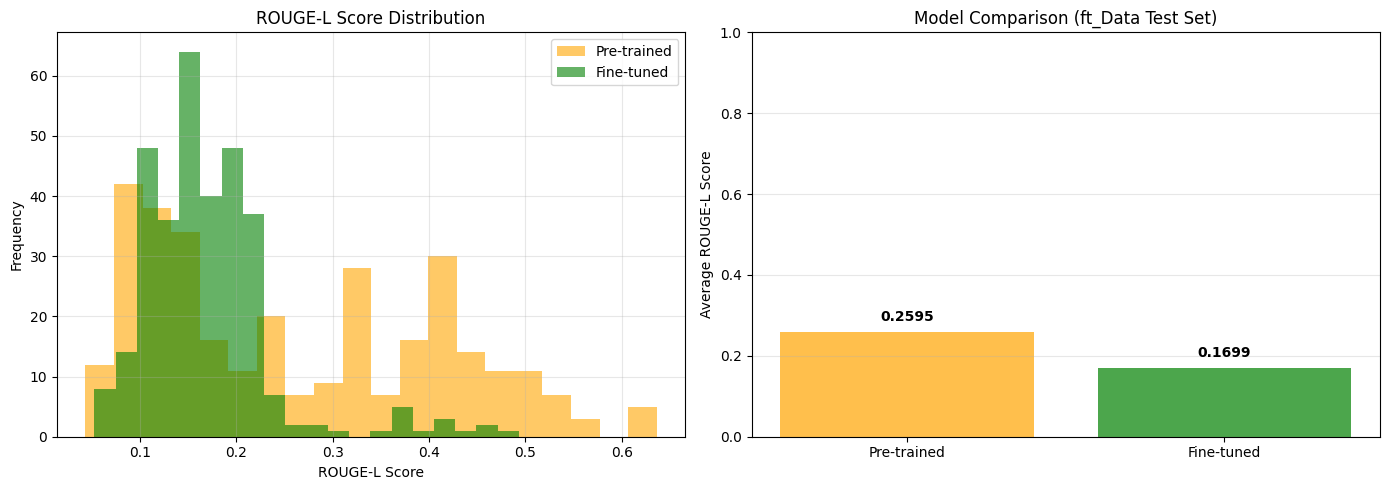

✅ Plot saved to: /content/drive/MyDrive/fiubench_checkpoints/extension2/outputs/rouge_comparison.png


In [32]:
import matplotlib.pyplot as plt

print('\n' + '='*60)
print('ROUGE-L Visualization')
print('='*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pretrained_scores, alpha=0.6, label='Pre-trained', bins=20, color='orange')
axes[0].hist(finetuned_scores, alpha=0.6, label='Fine-tuned', bins=20, color='green')
axes[0].set_xlabel('ROUGE-L Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('ROUGE-L Score Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

models = ['Pre-trained', 'Fine-tuned']
averages = [pretrained_avg, finetuned_avg]
colors = ['orange', 'green']
axes[1].bar(models, averages, color=colors, alpha=0.7)
axes[1].set_ylabel('Average ROUGE-L Score')
axes[1].set_title('Model Comparison (ft_Data Test Set)')
axes[1].set_ylim([0, 1])
for i, v in enumerate(averages):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rouge_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'✅ Plot saved to: {OUTPUT_DIR / "rouge_comparison.png"}')